In [60]:
import numpy as np
import pandas as pd

In [61]:
df = pd.read_excel('/content/Customer Churn-Dataset.xlsx')

In [62]:
#back up
new = df.copy()

In [63]:
new.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [64]:
df.shape

(7043, 23)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [66]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,numAdminTickets,numTechTickets
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.515689,0.419566
std,0.368612,24.559481,30.090047,1.275299,1.250117
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,0.000000,0.000000
75%,0.000000,55.000000,89.850000,0.000000,0.000000
max,1.000000,72.000000,118.750000,5.000000,9.000000


data cleaning

In [67]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [68]:
df.isnull().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'numadmintickets',
       'numtechtickets', 'churn'],
      dtype='object')

In [71]:
df.drop(columns='customerid',inplace=True)

In [72]:
df['multiplelines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [73]:
df['multiplelines'] = df['multiplelines'].str.replace('No phone service','No')
df['multiplelines'].unique()

array(['No', 'Yes'], dtype=object)

In [74]:
def get_unique(data):
  for col in data.columns:
    if data[col].dtypes == 'object':
      print(f'this {col} has {data[col].unique()} unique values')

In [75]:
get_unique(df)

this gender has ['Female' 'Male'] unique values
this partner has ['Yes' 'No'] unique values
this dependents has ['No' 'Yes'] unique values
this phoneservice has ['No' 'Yes'] unique values
this multiplelines has ['No' 'Yes'] unique values
this internetservice has ['DSL' 'Fiber optic' 'No'] unique values
this onlinesecurity has ['No' 'Yes' 'No internet service'] unique values
this onlinebackup has ['Yes' 'No' 'No internet service'] unique values
this deviceprotection has ['No' 'Yes' 'No internet service'] unique values
this techsupport has ['No' 'Yes' 'No internet service'] unique values
this streamingtv has ['No' 'Yes' 'No internet service'] unique values
this streamingmovies has ['No' 'Yes' 'No internet service'] unique values
this contract has ['Month-to-month' 'One year' 'Two year'] unique values
this paperlessbilling has ['Yes' 'No'] unique values
this paymentmethod has ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] unique values
this tota

In [76]:
some_features = ['onlinesecurity','onlinebackup' ,'deviceprotection','techsupport','streamingtv','streamingmovies']

def fix_category(some_features):
  for col in some_features:
    df[col] = df[col].str.replace('No internet service','No').astype('category')

fix_category(some_features)

In [77]:
get_unique(df)

this gender has ['Female' 'Male'] unique values
this partner has ['Yes' 'No'] unique values
this dependents has ['No' 'Yes'] unique values
this phoneservice has ['No' 'Yes'] unique values
this multiplelines has ['No' 'Yes'] unique values
this internetservice has ['DSL' 'Fiber optic' 'No'] unique values
this contract has ['Month-to-month' 'One year' 'Two year'] unique values
this paperlessbilling has ['Yes' 'No'] unique values
this paymentmethod has ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] unique values
this totalcharges has [29.85 1889.5 108.15 ... 346.45 306.6 6844.5] unique values
this churn has ['No' 'Yes'] unique values


In [78]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].median())

In [79]:
get_unique(df)

this gender has ['Female' 'Male'] unique values
this partner has ['Yes' 'No'] unique values
this dependents has ['No' 'Yes'] unique values
this phoneservice has ['No' 'Yes'] unique values
this multiplelines has ['No' 'Yes'] unique values
this internetservice has ['DSL' 'Fiber optic' 'No'] unique values
this contract has ['Month-to-month' 'One year' 'Two year'] unique values
this paperlessbilling has ['Yes' 'No'] unique values
this paymentmethod has ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] unique values
this churn has ['No' 'Yes'] unique values


In [80]:
cat_cols = ['seniorcitizen', 'partner','gender', 'dependents','phoneservice','multiplelines','internetservice','paperlessbilling','churn','onlinesecurity','onlinebackup' ,'deviceprotection','techsupport','streamingtv','streamingmovies','contract','paymentmethod']

def change_to_category(cat_cols):
  for col in cat_cols:
    df[col] = df[col].astype('category')

change_to_category(cat_cols)

In [81]:
cat_df = df[cat_cols]

In [82]:
cat_df.loc[:, 'contract'] = cat_df['contract'].str.replace('Month-to-month','monthly')

/tmp/ipykernel_31458/1683376056.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['monthly' 'One year' 'monthly' ... 'monthly' 'monthly' 'Two year']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  cat_df.loc[:, 'contract'] = cat_df['contract'].str.replace('Month-to-month','monthly')


In [83]:
cat_df.loc[:,'paymentmethod'] = cat_df['paymentmethod'].str.split().str[0].replace('Mailed','Mail')

/tmp/ipykernel_31458/2603067995.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Electronic' 'Mail' 'Mail' ... 'Electronic' 'Mail' 'Bank']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  cat_df.loc[:,'paymentmethod'] = cat_df['paymentmethod'].str.split().str[0].replace('Mailed','Mail')


In [84]:
cat_df.columns = cat_df.columns.str.title()

In [85]:
mask = {
    'Yes':1,
    "No" :0,
    'monthly':0,
    'One year':1,
    'Two year':2,
    'Electronic':0,
    'Bank':1,
    'Credit':2,
    'Mail':3,
    'DSL':1,
    'Fiber optic':2,
    'Male':1,
    'Female':0
}

cat_df = cat_df.replace(mask)

/tmp/ipykernel_31458/321026635.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cat_df = cat_df.replace(mask)
/tmp/ipykernel_31458/321026635.py:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cat_df = cat_df.replace(mask)
/tmp/ipykernel_31458/321026635.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cat_df = 

In [86]:
cat_df

,Seniorcitizen,Partner,Gender,Dependents,Phoneservice,Multiplelines,Internetservice,Paperlessbilling,Churn,Onlinesecurity,Onlinebackup,Deviceprotection,Techsupport,Streamingtv,Streamingmovies,Contract,Paymentmethod
0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0
1,0,0,1,0,1,0,1,0,0,1,0,1,0,0,0,1,3
2,0,0,1,0,1,0,1,1,1,1,1,0,0,0,0,0,3
3,0,0,1,0,0,0,1,0,0,1,0,1,1,0,0,1,1
4,0,0,0,0,1,0,2,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,1,1,1,1,1,0,1,0,1,1,1,1,1,3
7039,0,1,0,1,1,1,2,1,0,0,1,1,0,1,1,1,2
7040,0,1,0,1,0,0,1,1,0,1,0,0,0,0,0,0,0
7041,1,1,1,0,1,1,2,1,1,0,0,0,0,0,0,0,3


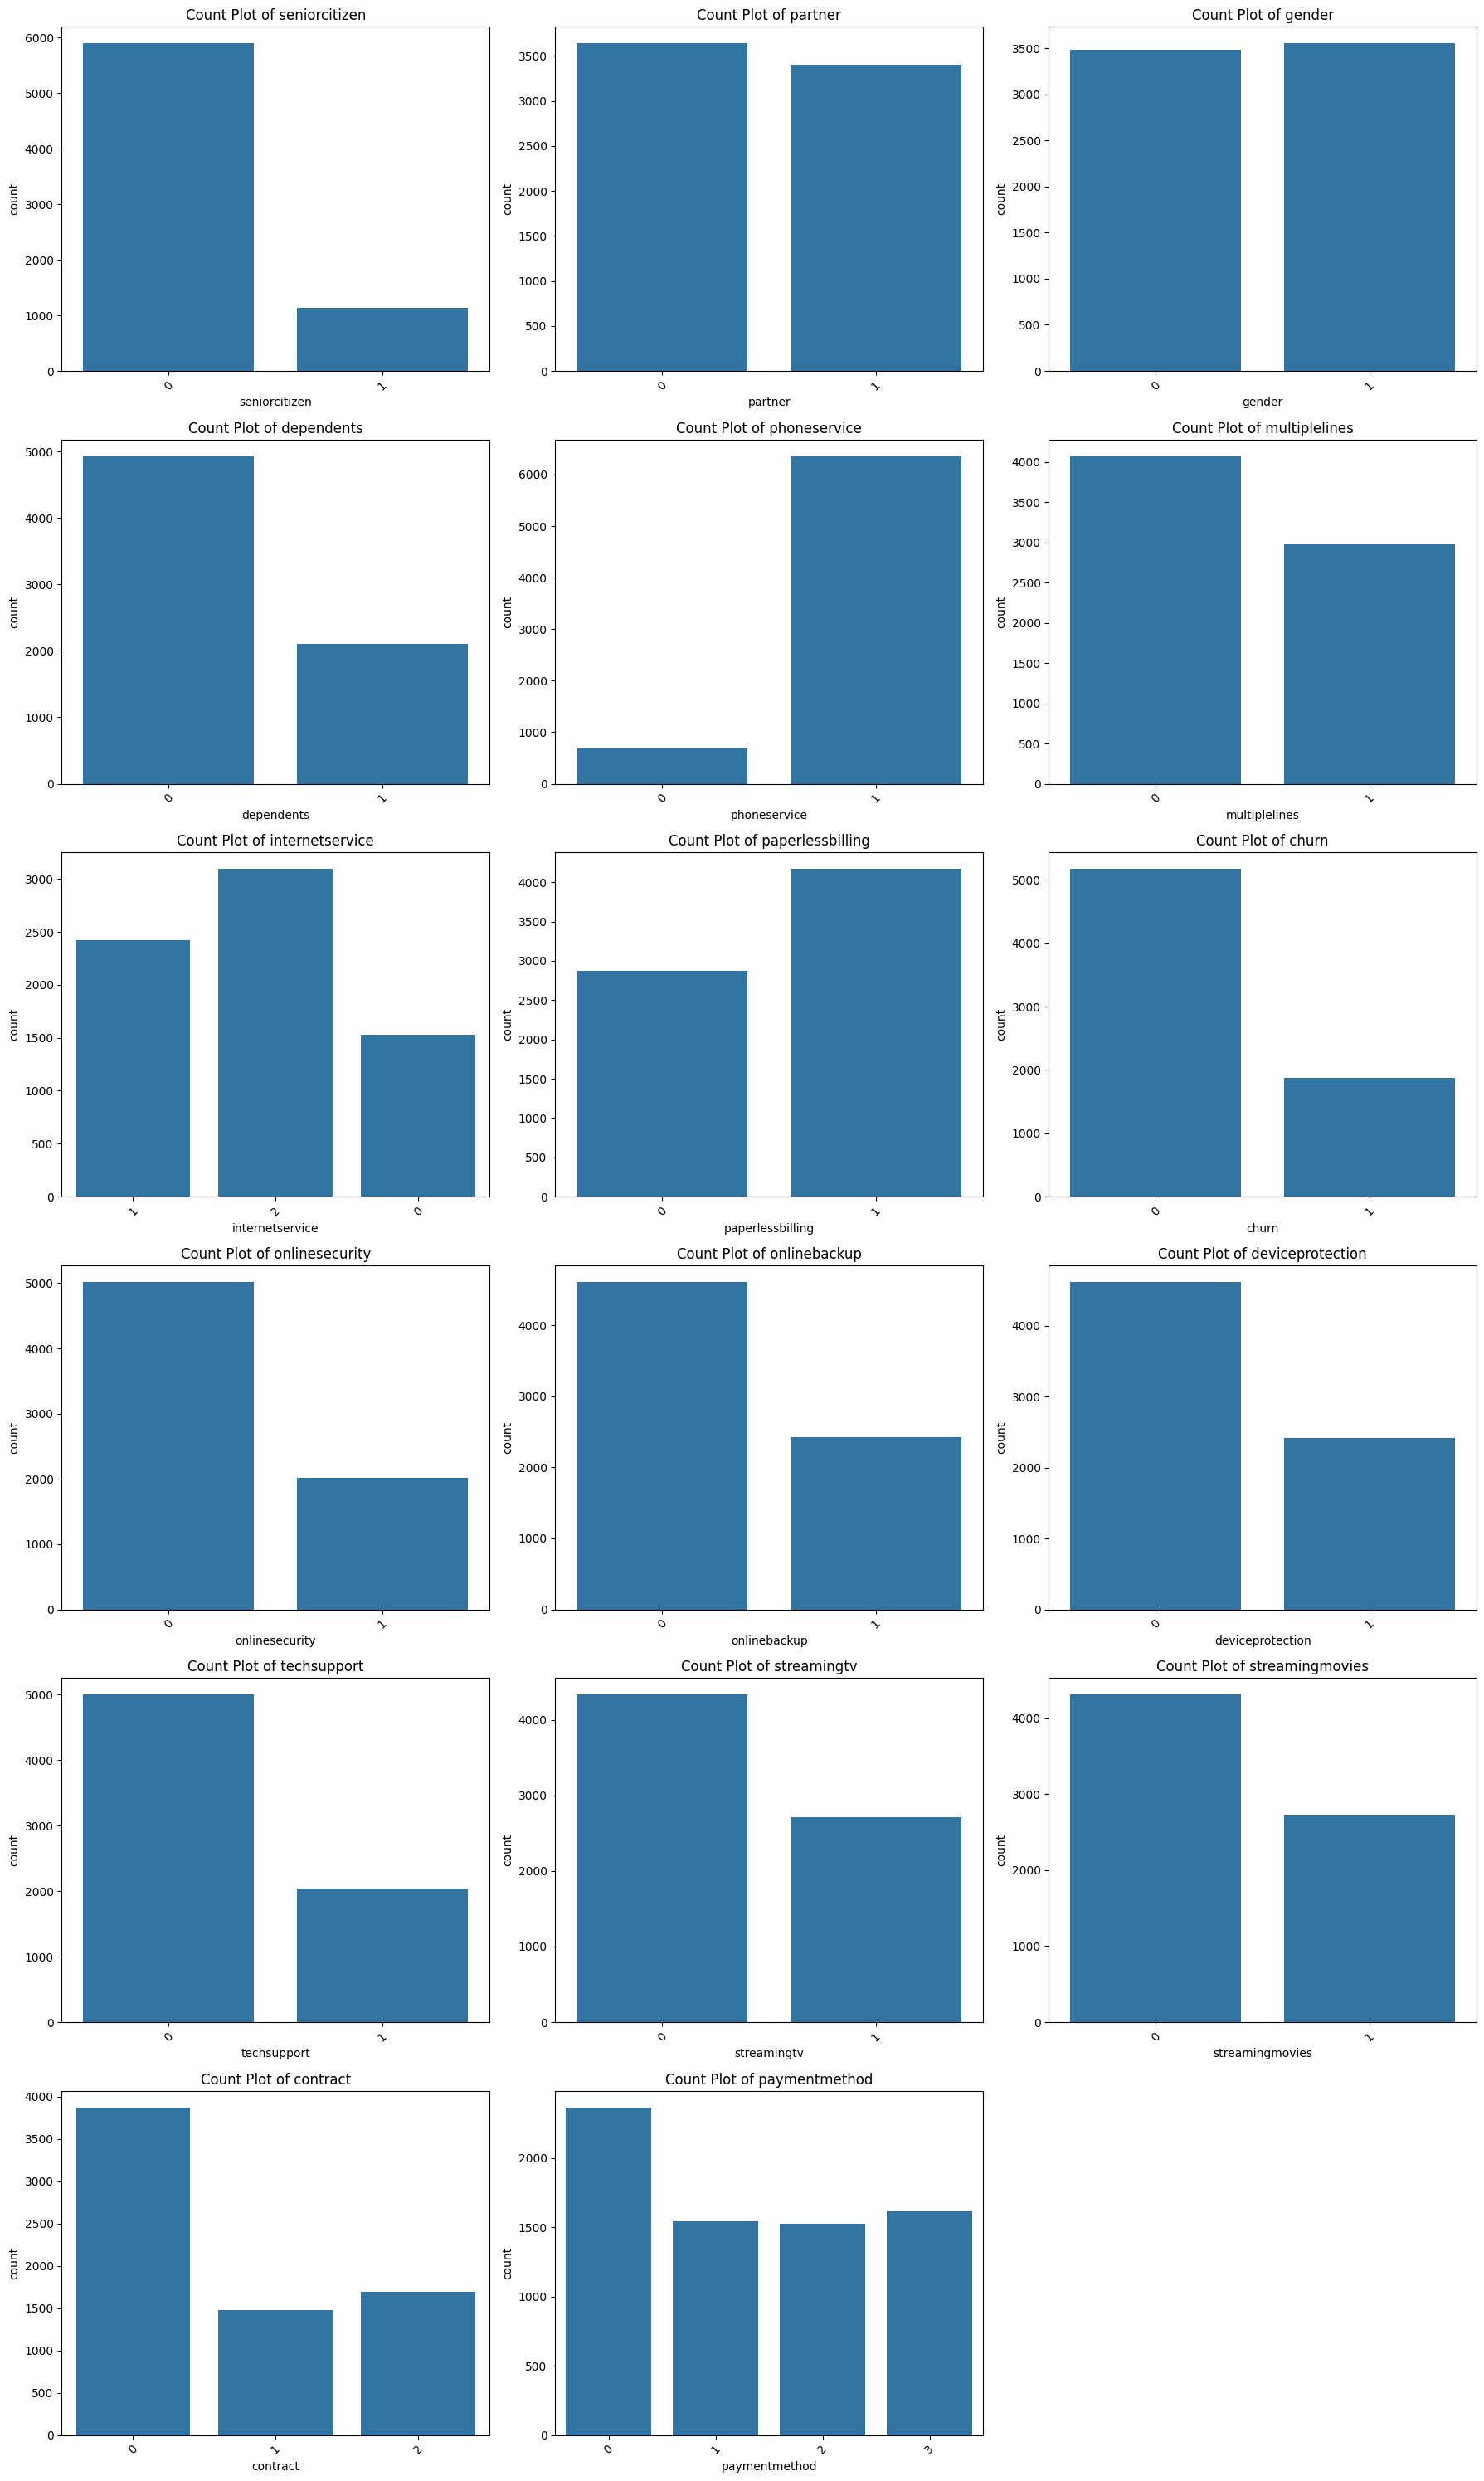

In [87]:
import math

def plot_category(df ,cols):
  num_cols = len(cols)
  num_rows = math.ceil(num_cols / 3)

  fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows))
  axes = axes.flatten()

  for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

  # Hide any unused subplots
  for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

# Ensure cat_df columns are lowercase to match cat_cols
cat_df.columns = cat_df.columns.str.lower()
plot_category(cat_df,cat_cols)

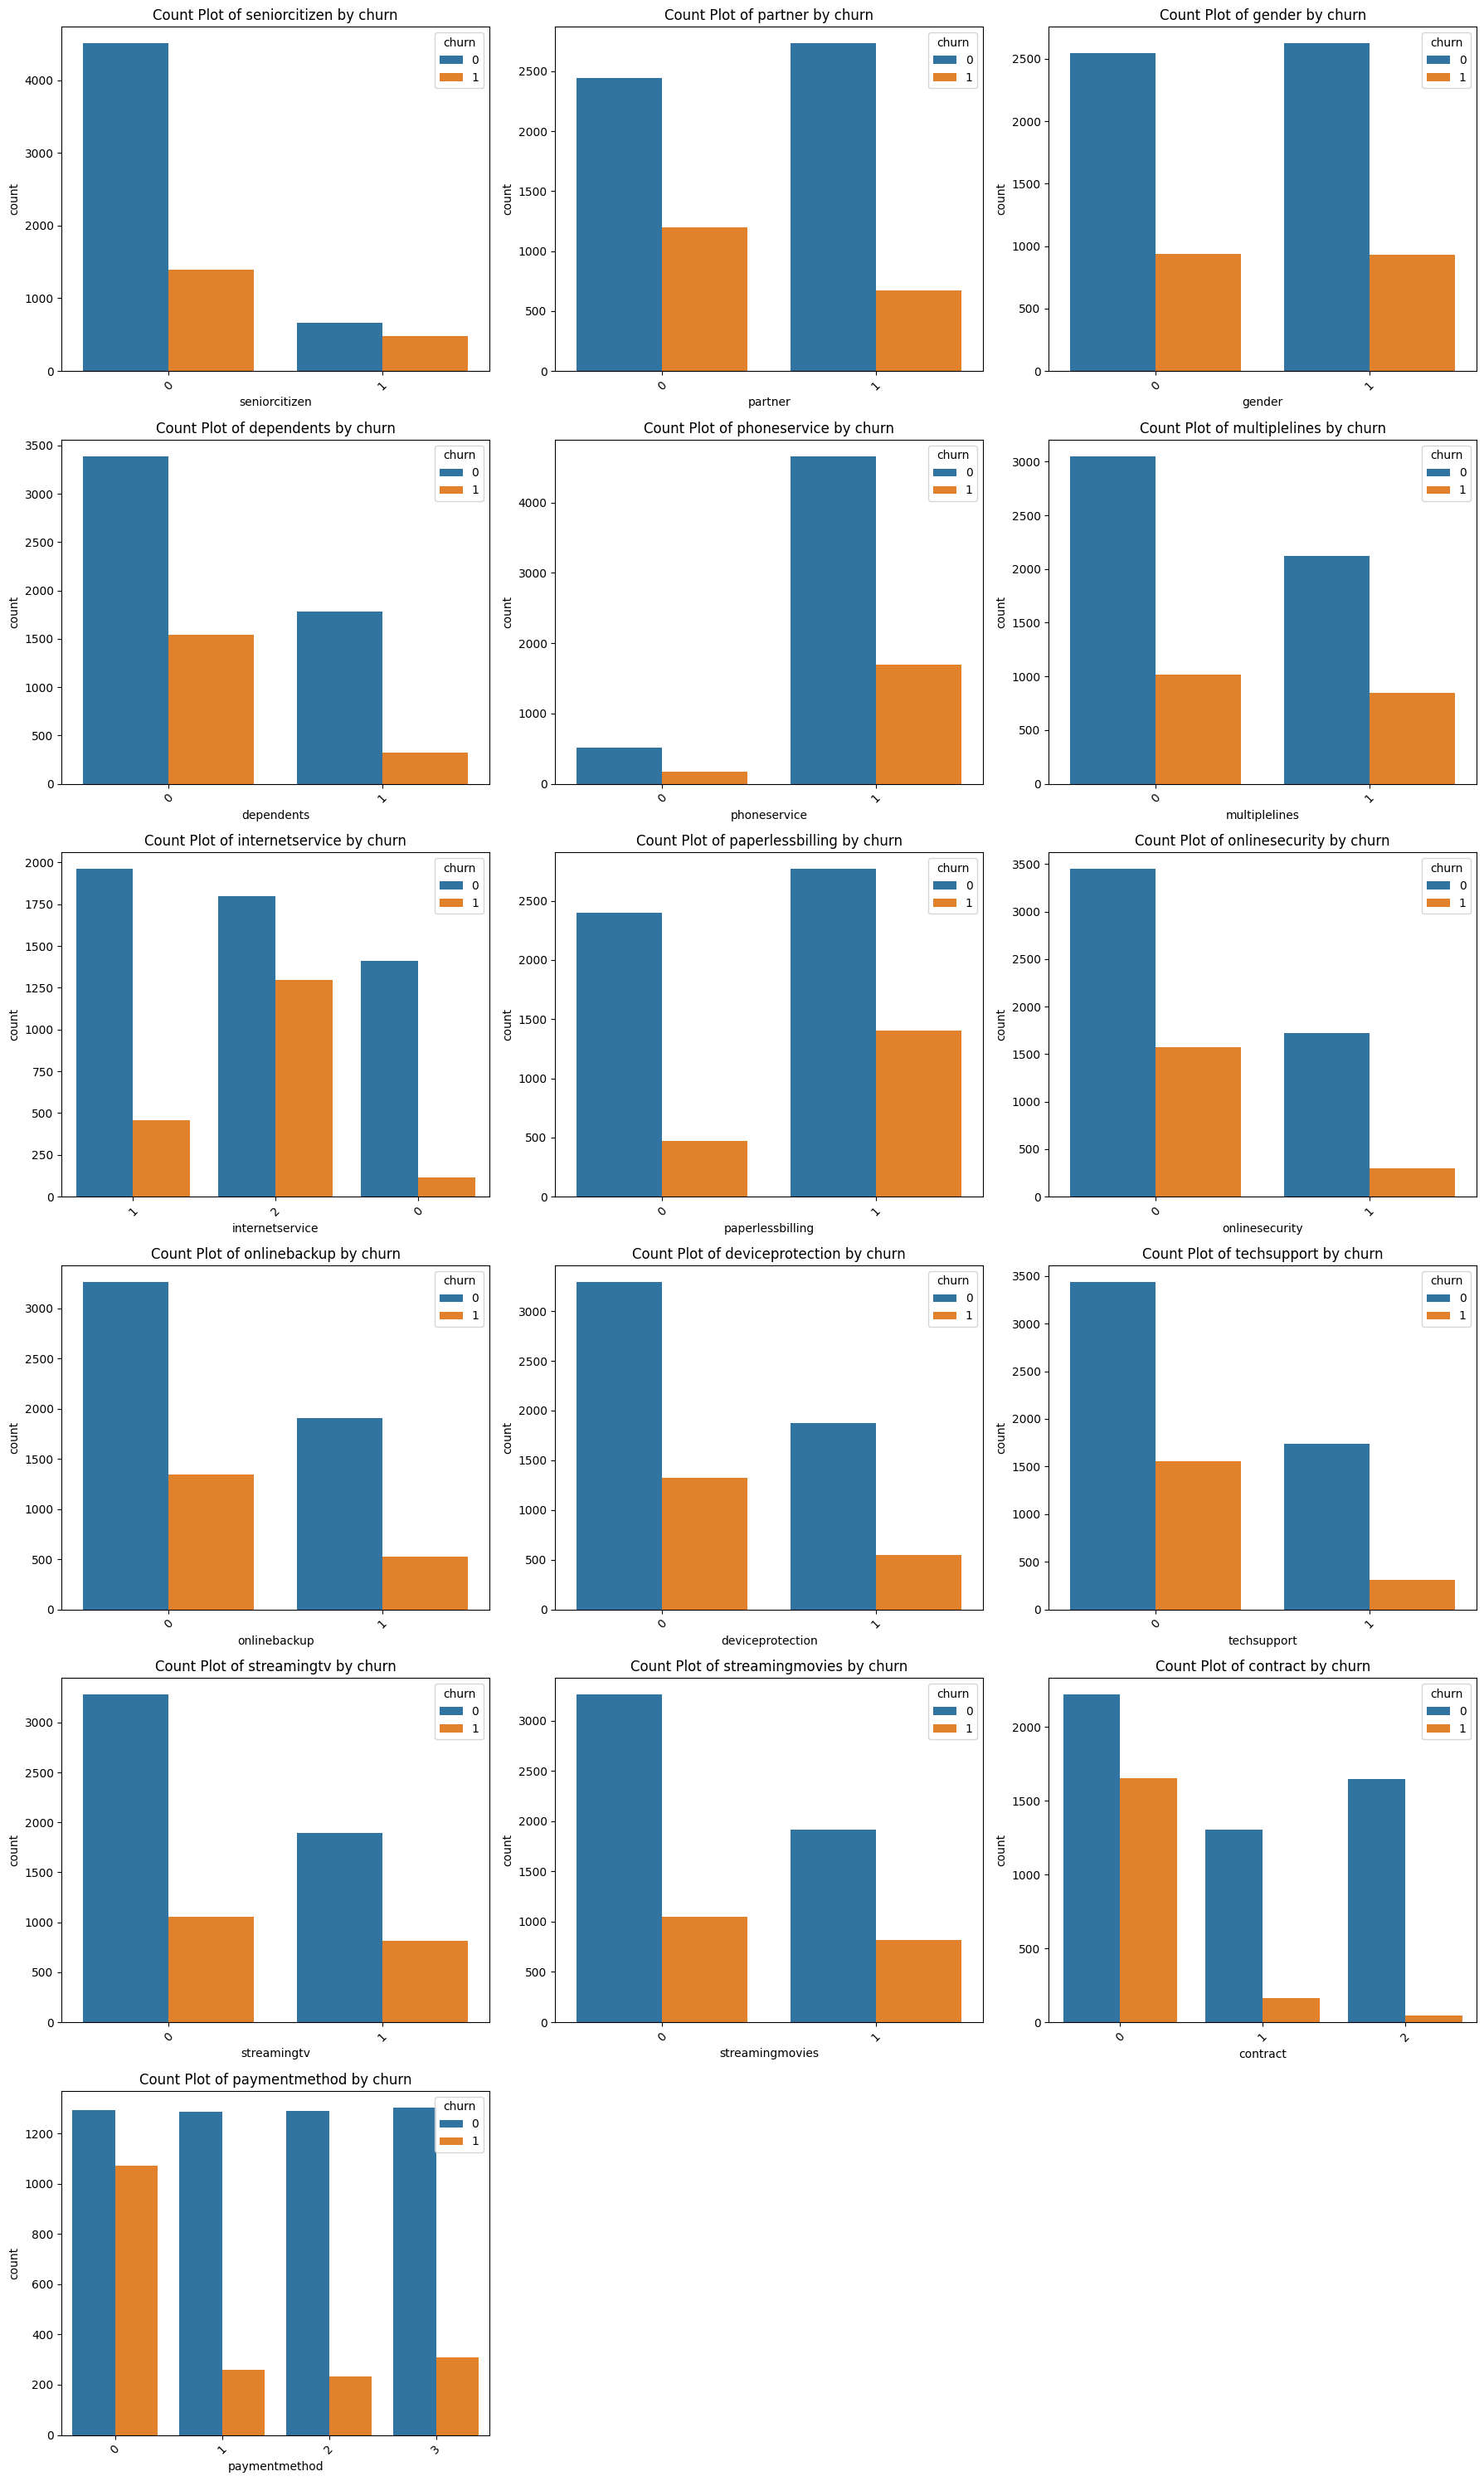

In [88]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_churn_relationship(df, categorical_features, hue_col):
    # Filter out the hue_col from the features to plot as x
    features_to_plot = [col for col in categorical_features if col != hue_col]

    num_cols_to_plot = len(features_to_plot)
    if num_cols_to_plot == 0:
        print(f"No categorical features to plot against '{hue_col}'.")
        return

    # Determine grid size for subplots
    num_rows = math.ceil(num_cols_to_plot / 3) # Max 3 plots per row
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(features_to_plot):
        sns.countplot(x=col, data=df, hue=hue_col, ax=axes[i])
        axes[i].set_title(f'Count Plot of {col} by {hue_col}')
        axes[i].tick_params(axis='x', rotation=45) # Rotate labels for readability, removed 'ha'

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Call the function with cat_df, cat_cols, and 'churn' as the hue variable
plot_categorical_churn_relationship(cat_df, cat_cols, 'churn')

In [89]:
numeric_cols = [x for x in df.columns if df[x].dtype == 'float64' or df[x].dtype == 'int64']

In [90]:
numeric_cols

['tenure',
 'monthlycharges',
 'totalcharges',
 'numadmintickets',
 'numtechtickets']

In [91]:
num_df = df[numeric_cols]

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

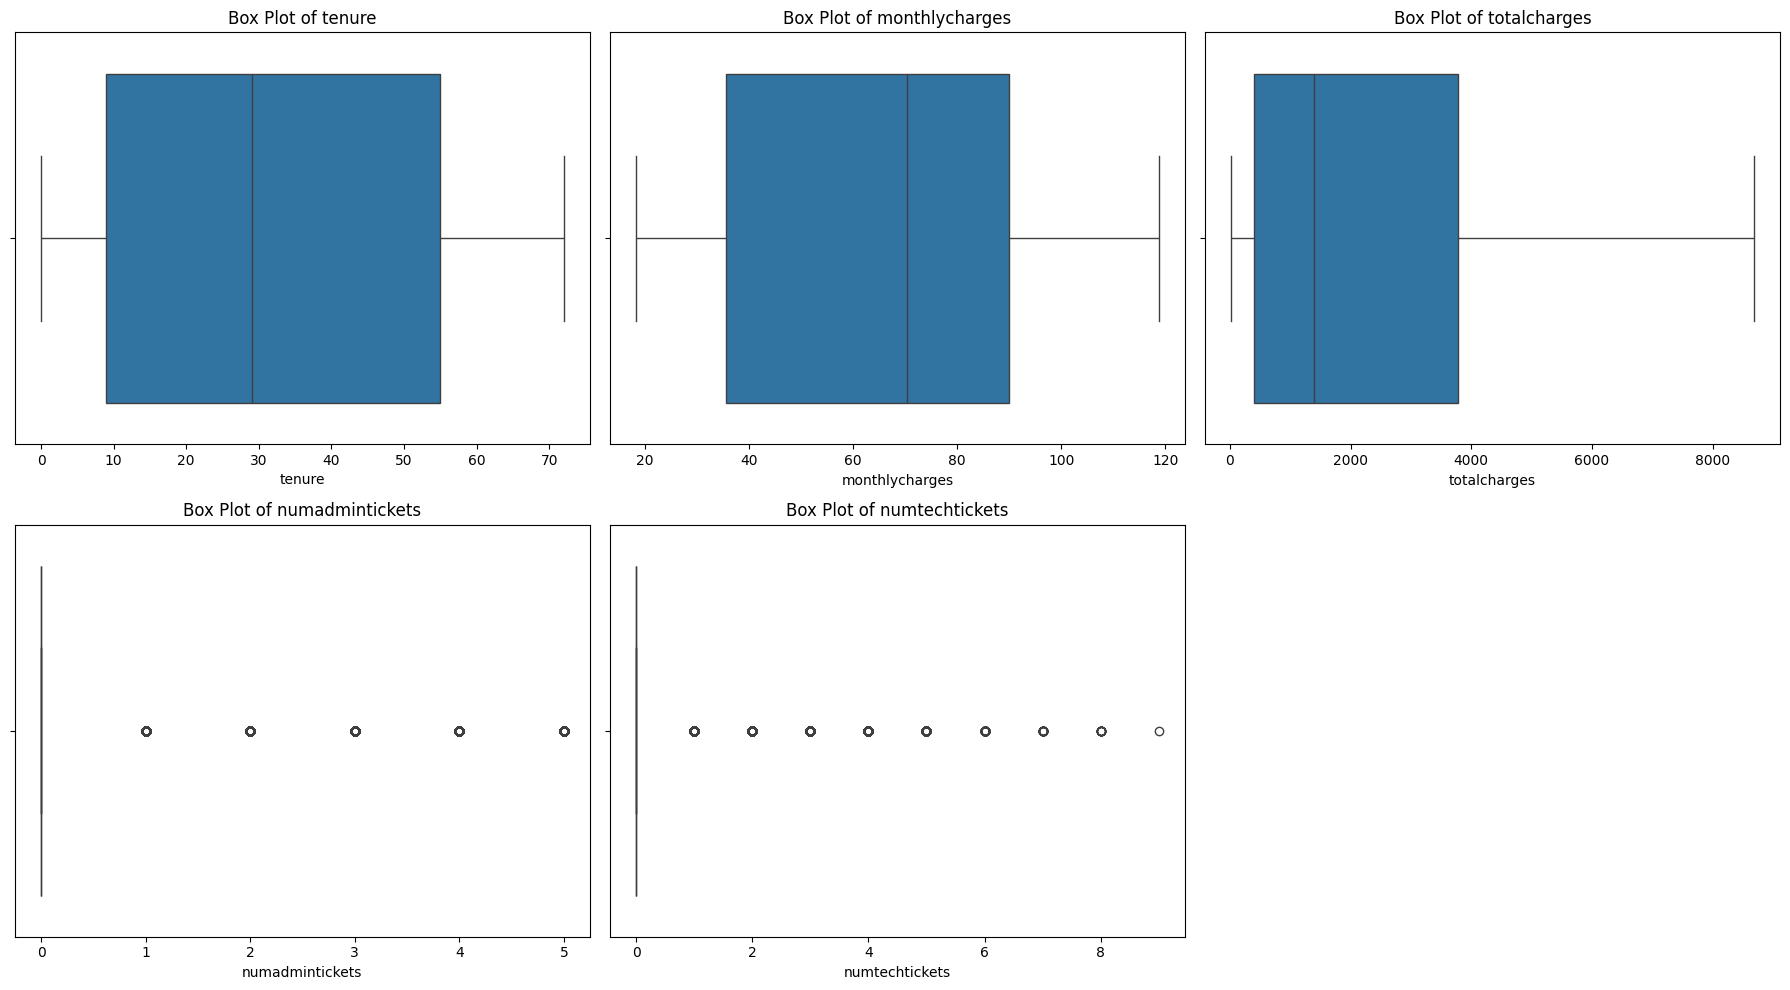

In [93]:
import math

def draw_numeric(df,cols):
  num_cols = len(cols)
  num_rows = math.ceil(num_cols / 3)

  fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows))
  axes = axes.flatten()
  for i, col in enumerate(cols):
    sns.boxplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

  # Hide any unused subplots
  for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

draw_numeric(df,numeric_cols)

<Axes: >

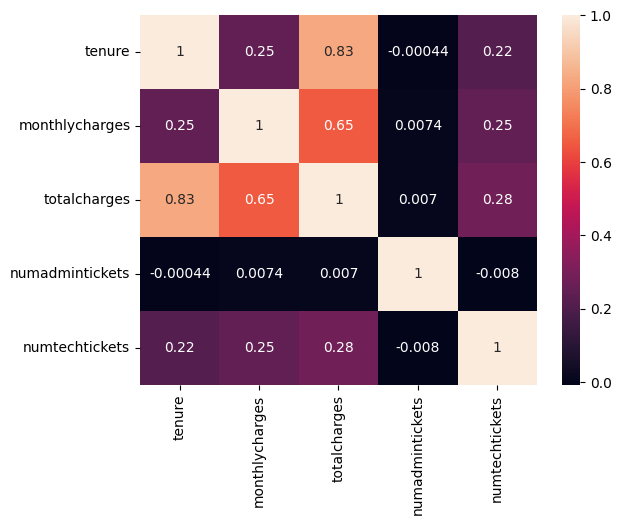

In [94]:
sns.heatmap(df[numeric_cols].corr(),annot=True)

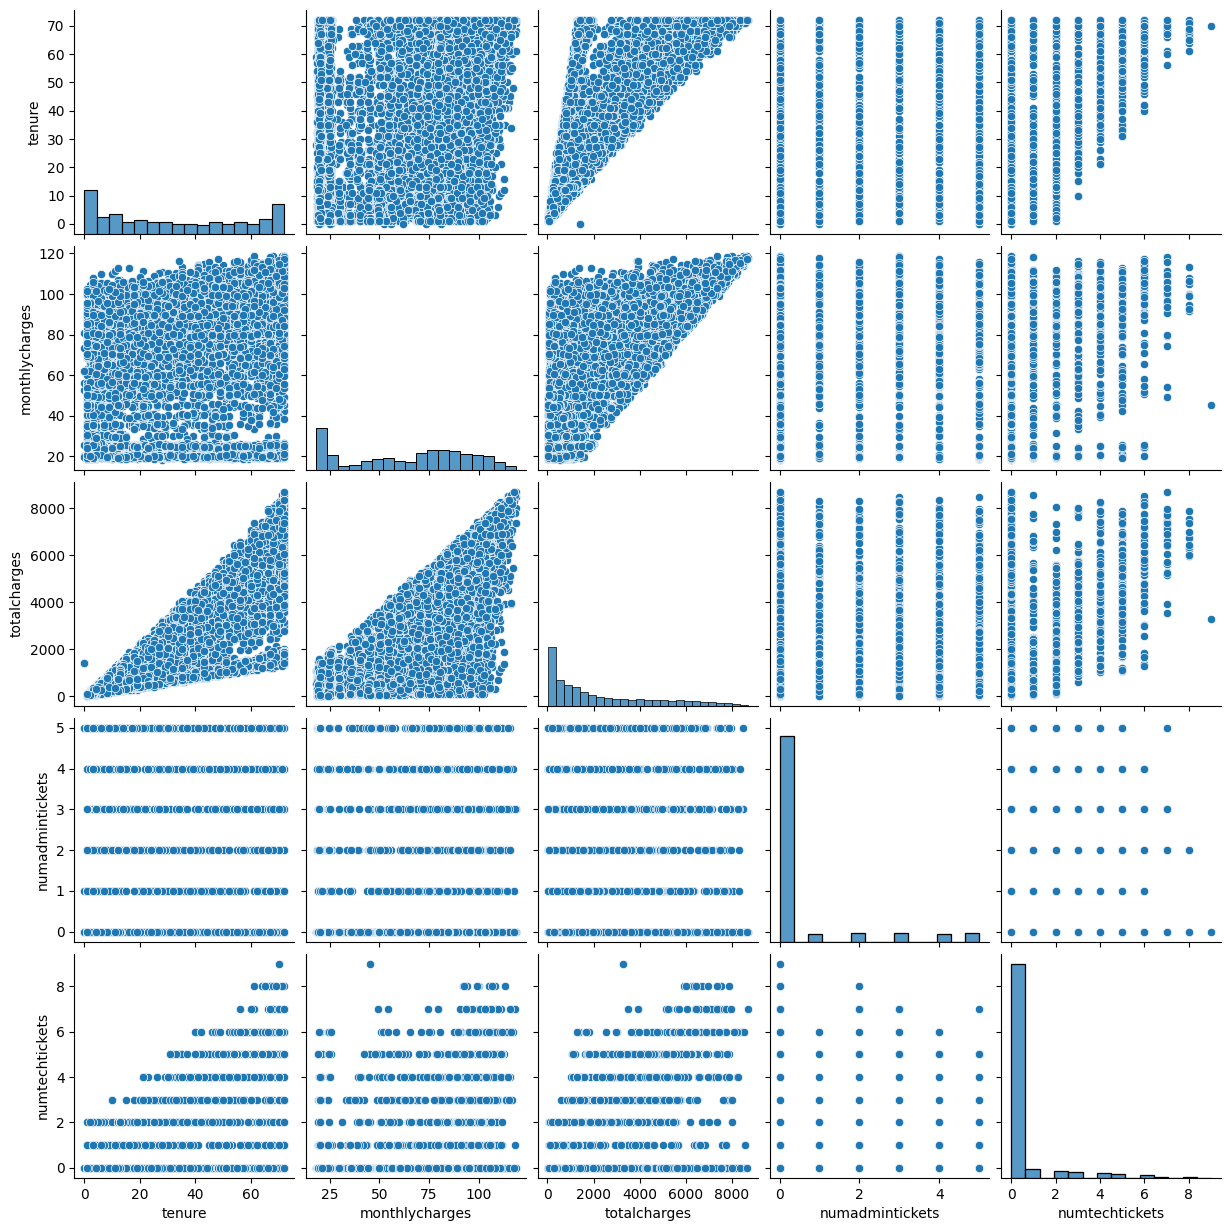

In [95]:
sns.pairplot(df[numeric_cols])

In [101]:
#making each numeric vlaues to be normally distributed
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
num_df[numeric_cols]= pt.fit_transform(num_df[numeric_cols])

/tmp/ipykernel_31458/2766000168.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  num_df[numeric_cols]= pt.fit_transform(num_df[numeric_cols])


In [102]:
num_df

,tenure,monthlycharges,totalcharges,numadmintickets,numtechtickets
0,-1.644343,-1.158541,-1.811104,-0.453303,-0.399632
1,0.297205,-0.239492,0.254277,-0.453303,-0.399632
2,-1.495444,-0.342665,-1.387090,-0.453303,-0.399632
3,0.646327,-0.731079,0.233221,-0.453303,2.519888
4,-1.495444,0.213545,-1.249770,-0.453303,-0.399632
...,...,...,...,...,...
7038,-0.078084,0.671510,0.296643,-0.453303,-0.399632
7039,1.342198,1.260981,1.567315,-0.453303,2.521235
7040,-0.725121,-1.167241,-0.859191,-0.453303,-0.399632
7041,-1.265130,0.334312,-0.922307,-0.453303,-0.399632


In [103]:
# creating the final data

final_data= pd.concat([cat_df,num_df],axis=1)

In [99]:
# final_data.to_csv('cleaned_data.csv')

model training


In [104]:
X = final_data.drop(columns='churn')
y = final_data['churn']

In [105]:
X

,seniorcitizen,partner,gender,dependents,phoneservice,multiplelines,internetservice,paperlessbilling,onlinesecurity,onlinebackup,...,techsupport,streamingtv,streamingmovies,contract,paymentmethod,tenure,monthlycharges,totalcharges,numadmintickets,numtechtickets
0,0,1,0,0,0,0,1,1,0,1,...,0,0,0,0,0,-1.644343,-1.158541,-1.811104,-0.453303,-0.399632
1,0,0,1,0,1,0,1,0,1,0,...,0,0,0,1,3,0.297205,-0.239492,0.254277,-0.453303,-0.399632
2,0,0,1,0,1,0,1,1,1,1,...,0,0,0,0,3,-1.495444,-0.342665,-1.387090,-0.453303,-0.399632
3,0,0,1,0,0,0,1,0,1,0,...,1,0,0,1,1,0.646327,-0.731079,0.233221,-0.453303,2.519888
4,0,0,0,0,1,0,2,1,0,0,...,0,0,0,0,0,-1.495444,0.213545,-1.249770,-0.453303,-0.399632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,1,1,1,1,1,1,0,...,1,1,1,1,3,-0.078084,0.671510,0.296643,-0.453303,-0.399632
7039,0,1,0,1,1,1,2,1,0,1,...,0,1,1,1,2,1.342198,1.260981,1.567315,-0.453303,2.521235
7040,0,1,0,1,0,0,1,1,1,0,...,0,0,0,0,0,-0.725121,-1.167241,-0.859191,-0.453303,-0.399632
7041,1,1,1,0,1,1,2,1,0,0,...,0,0,0,0,3,-1.265130,0.334312,-0.922307,-0.453303,-0.399632


In [125]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score , accuracy_score , confusion_matrix , classification_report

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 21), (1409, 21), (5634,), (1409,))

In [110]:
from sklearn.compose import make_column_transformer

In [112]:
clf1 = LinearRegression()
clf1.fit(X_train,y_train)

y_pred = clf1.predict(X_test)

print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('Accuracy',accuracy_score(y_test,y_pred.round()))

MAE: 0.24534782042126374
MSE: 0.1048640299189149
RMSE: 0.32382716056395716
Accuracy 0.8559261887863733


In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB , BernoulliNB
from sklearn.model_selection import cross_val_score

### Model Performance Comparison

Now, let's train each classifier individually, make predictions, and gather their performance metrics, including the previously calculated cross-validation scores, into a DataFrame for easy comparison.

In [153]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

# Re-calculate cross-validation scores for all models to ensure robustness
clf_lr_cv = cross_val_score(LogisticRegression(C=0.1 ,penalty='l2',max_iter=200,n_jobs=-1), X_train, y_train, cv=5)
clf_svc_cv = cross_val_score(SVC(kernel='rbf',degree=5), X_train, y_train, cv=5)
clf_dt_cv = cross_val_score(DecisionTreeClassifier(random_state=42), X_train, y_train, cv=5)
clf_rf_cv = cross_val_score(RandomForestClassifier(n_estimators=100), X_train, y_train, cv=5)
clf_knn_cv = cross_val_score(KNeighborsClassifier(n_neighbors=3), X_train, y_train, cv=5)
clf_gnb_cv = cross_val_score(GaussianNB(), X_train, y_train, cv=5)
clf_bnb_cv = cross_val_score(BernoulliNB(), X_train, y_train, cv=5)
clf_et_cv = cross_val_score(ExtraTreesClassifier(n_estimators=100, random_state=42), X_train, y_train, cv=5)
clf_xgb_cv = cross_val_score(XGBClassifier(random_state=42, enable_categorical=True), X_train, y_train, cv=5)

# Redefine the dictionary of classifiers including Extra Trees and XGBoost
classifiers = {
    'Logistic Regression': (LogisticRegression(C=0.1, penalty='l2', max_iter=200, n_jobs=-1), clf_lr_cv),
    'SVC': (SVC(kernel='rbf', degree=5), clf_svc_cv),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), clf_dt_cv),
    'Random Forest': (RandomForestClassifier(n_estimators=100), clf_rf_cv),
    'KNeighbors': (KNeighborsClassifier(n_neighbors=3), clf_knn_cv),
    'Gaussian NB': (GaussianNB(), clf_gnb_cv),
    'Bernoulli NB': (BernoulliNB(), clf_bnb_cv),
    'Extra Trees': (ExtraTreesClassifier(n_estimators=100, random_state=42), clf_et_cv),
    'XGBoost': (XGBClassifier(random_state=42, enable_categorical=True), clf_xgb_cv)
}

results = []

for name, (model, cv_scores) in classifiers.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Cross-Validation Scores (Mean)': np.mean(cv_scores),
        'Cross-Validation Scores (Std)': np.std(cv_scores)
    })

# Create a DataFrame from the results
performance_df = pd.DataFrame(results)

# Display the updated performance DataFrame
print('Updated Model Performance Summary:')
display(performance_df.sort_values(by='Accuracy', ascending=False))

Updated Model Performance Summary:


,Model,Accuracy,Precision,Cross-Validation Scores (Mean),Cross-Validation Scores (Std)
3,Random Forest,0.860894,0.761062,0.853036,0.002974
8,XGBoost,0.855216,0.743516,0.851083,0.005320
0,Logistic Regression,0.853087,0.742690,0.849485,0.005854
1,SVC,0.853087,0.747024,0.853923,0.007474
7,Extra Trees,0.842441,0.729483,0.840966,0.006859
4,KNeighbors,0.825408,0.667546,0.820554,0.006291
5,Gaussian NB,0.818311,0.619632,0.808840,0.005834
6,Bernoulli NB,0.816182,0.627232,0.799610,0.008556
2,Decision Tree,0.798439,0.615584,0.812744,0.011097


In [152]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42, enable_categorical=True)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Accuracy',accuracy_score(y_test, y_pred))
print('confusion matrix',confusion_matrix(y_test, y_pred))
print('classification report',classification_report(y_test, y_pred))

Accuracy 0.8552164655784245
confusion matrix [[947  89]
 [115 258]]
classification report               precision    recall  f1-score   support

           0       0.89      0.91      0.90      1036
           1       0.74      0.69      0.72       373

    accuracy                           0.86      1409
   macro avg       0.82      0.80      0.81      1409
weighted avg       0.85      0.86      0.85      1409



ensemble techniques


In [154]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score
import numpy as np
import pandas as pd

# Initialize new ensemble classifiers
clf_bagging_cv = cross_val_score(BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42), X_train, y_train, cv=5)
clf_adaboost_cv = cross_val_score(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42), X_train, y_train, cv=5)
clf_gradboost_cv = cross_val_score(GradientBoostingClassifier(n_estimators=100, random_state=42), X_train, y_train, cv=5)

# Extend the existing dictionary of classifiers to include new ensemble models
new_classifiers = {
    'Bagging Classifier': (BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42), clf_bagging_cv),
    'AdaBoost Classifier': (AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42), clf_adaboost_cv),
    'Gradient Boosting Classifier': (GradientBoostingClassifier(n_estimators=100, random_state=42), clf_gradboost_cv)
}

# Append new classifiers to the existing classifiers dictionary
classifiers.update(new_classifiers)

results = []

for name, (model, cv_scores) in classifiers.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Cross-Validation Scores (Mean)': np.mean(cv_scores),
        'Cross-Validation Scores (Std)': np.std(cv_scores)
    })

# Create a DataFrame from the results
performance_df = pd.DataFrame(results)

# Display the updated performance DataFrame
print('Updated Model Performance Summary with new Ensemble Techniques:')
display(performance_df.sort_values(by='Accuracy', ascending=False))

Updated Model Performance Summary with new Ensemble Techniques:


,Model,Accuracy,Precision,Cross-Validation Scores (Mean),Cross-Validation Scores (Std)
11,Gradient Boosting Classifier,0.865153,0.759207,0.857828,0.006288
8,XGBoost,0.855216,0.743516,0.851083,0.005320
3,Random Forest,0.854507,0.748521,0.853036,0.002974
0,Logistic Regression,0.853087,0.742690,0.849485,0.005854
10,AdaBoost Classifier,0.853087,0.735795,0.850906,0.005037
1,SVC,0.853087,0.747024,0.853923,0.007474
9,Bagging Classifier,0.850248,0.743976,0.851970,0.004091
7,Extra Trees,0.842441,0.729483,0.840966,0.006859
4,KNeighbors,0.825408,0.667546,0.820554,0.006291
5,Gaussian NB,0.818311,0.619632,0.808840,0.005834


--- Applying PCA and Re-evaluating Models ---


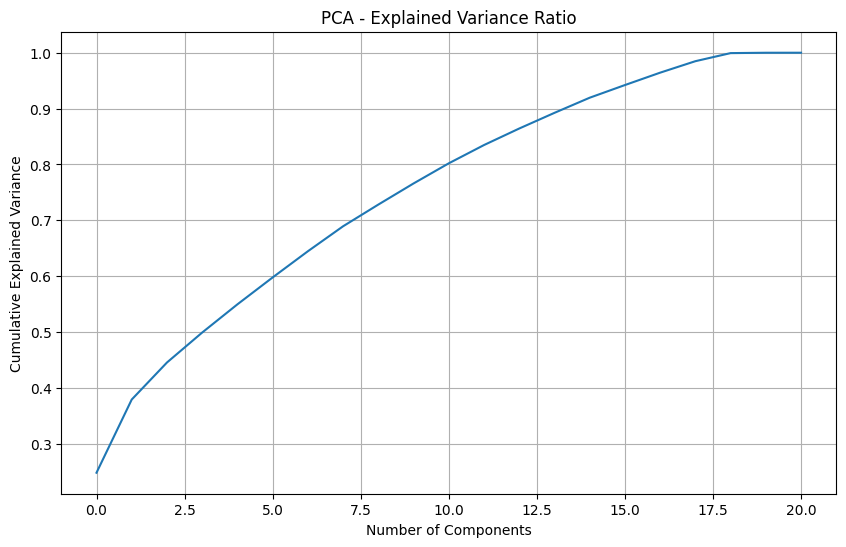

Number of components to retain 95% variance: 17
Original number of features: 21
Reduced number of features after PCA: 17

--- Re-evaluating Models with PCA-transformed Data ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(



--- Model Performance Summary After PCA ---


,Model,Accuracy,Precision,Cross-Validation Scores (Mean),Cross-Validation Scores (Std)
1,SVC,0.852378,0.732394,0.849309,0.007618
0,Logistic Regression,0.851668,0.741176,0.847178,0.005714
8,XGBoost,0.850958,0.733524,0.837592,0.008465
11,Gradient Boosting Classifier,0.850958,0.749235,0.845223,0.008607
3,Random Forest,0.848119,0.735905,0.833688,0.009855
9,Bagging Classifier,0.839603,0.714286,0.834753,0.004427
7,Extra Trees,0.836764,0.725552,0.825522,0.006043
5,Gaussian NB,0.836764,0.714715,0.827475,0.004546
10,AdaBoost Classifier,0.836764,0.717325,0.833511,0.010419
4,KNeighbors,0.811923,0.653409,0.810436,0.006478


In [155]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB , BernoulliNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

print('--- Applying PCA and Re-evaluating Models ---')

# 1. Scale the data before applying PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame to preserve column names (optional, but good for debugging)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# 2. Apply PCA
pca = PCA(n_components=None)
pca.fit(X_train_scaled_df)

# Plot explained variance to decide on n_components
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance Ratio')
plt.grid(True)
plt.show()

# Let's choose a number of components, for example, to retain 95% variance
# Or we can inspect the plot and pick a reasonable elbow point.
# For demonstration, let's pick components that explain 95% of variance
n_components_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components to retain 95% variance: {n_components_95}")

pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled_df)
X_test_pca = pca.transform(X_test_scaled_df)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features after PCA: {X_train_pca.shape[1]}")

# 3. Re-evaluate Models with PCA-transformed data
print('\n--- Re-evaluating Models with PCA-transformed Data ---')

# Re-initialize classifiers (some might need n_jobs=-1, ensure it's compatible with PCA output)
classifiers_pca = {
    'Logistic Regression': (LogisticRegression(C=0.1, penalty='l2', max_iter=200, n_jobs=-1, solver='liblinear'), None),
    'SVC': (SVC(kernel='rbf', degree=5), None),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), None),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), None),
    'KNeighbors': (KNeighborsClassifier(n_neighbors=3, n_jobs=-1), None),
    'Gaussian NB': (GaussianNB(), None),
    'Bernoulli NB': (BernoulliNB(), None),
    'Extra Trees': (ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1), None),
    'XGBoost': (XGBClassifier(random_state=42, enable_categorical=False), None), # XGBoost after PCA doesn't need categorical enabled
    'Bagging Classifier': (BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42, n_jobs=-1), None),
    'AdaBoost Classifier': (AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42), None),
    'Gradient Boosting Classifier': (GradientBoostingClassifier(n_estimators=100, random_state=42), None)
}

# Calculate cross-validation scores and train models
results_pca = []

for name, (model, _) in classifiers_pca.items():
    # Calculate cross-validation scores on PCA data
    cv_scores_pca = cross_val_score(model, X_train_pca, y_train, cv=5, n_jobs=-1 if hasattr(model, 'n_jobs') else None) # Use n_jobs for compatible models

    # Train the model
    model.fit(X_train_pca, y_train)

    # Make predictions
    y_pred_pca = model.predict(X_test_pca)

    # Calculate metrics
    accuracy_pca = accuracy_score(y_test, y_pred_pca)
    precision_pca = precision_score(y_test, y_pred_pca, zero_division=0)

    # Store results
    results_pca.append({
        'Model': name,
        'Accuracy': accuracy_pca,
        'Precision': precision_pca,
        'Cross-Validation Scores (Mean)': np.mean(cv_scores_pca),
        'Cross-Validation Scores (Std)': np.std(cv_scores_pca)
    })

# Create a DataFrame from the results
performance_df_pca = pd.DataFrame(results_pca)

# Display the updated performance DataFrame
print('\n--- Model Performance Summary After PCA ---')
display(performance_df_pca.sort_values(by='Accuracy', ascending=False))

In [159]:
# Reverting the numerical data to its original state (before PowerTransformation)
# Re-create num_df from the original df without transformation
# Ensure 'numeric_cols' are correctly defined as per earlier steps
numeric_cols_revert = [col for col in df.columns if df[col].dtype == 'float64' or df[col].dtype == 'int64']
num_df_no_transform = df[numeric_cols_revert].copy()

# Re-create final_data without PowerTransformation
final_data_no_transform = pd.concat([cat_df, num_df_no_transform], axis=1)

# Re-split the data
X_no_transform = final_data_no_transform.drop(columns='churn')
y_no_transform = final_data_no_transform['churn']

X_train_no_transform, X_test_no_transform, y_train_no_transform, y_test_no_transform = train_test_split(X_no_transform, y_no_transform, test_size=0.2, random_state=42)

print('--- Re-evaluating Models without PowerTransformation ---')

# We need to re-scale the numerical features within the models for cross-validation
# This time, we'll apply StandardScaler for each model's pipeline or directly before training.
# For tree-based models, scaling is often not strictly necessary, but good practice for consistency
# For SVC, Logistic Regression, KNeighbors, scaling is important.

# Re-initialize classifiers (some might need n_jobs=-1, ensure it's compatible with data)
# We'll use pipelines for models sensitive to scaling
from sklearn.pipeline import Pipeline

classifiers_no_transform = {
    'Logistic Regression': (Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(C=0.1, penalty='l2', max_iter=200, n_jobs=-1, solver='liblinear'))]), None),
    'SVC': (Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', degree=5))]), None),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), None),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), None),
    'KNeighbors': (Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=3, n_jobs=-1))]), None),
    'Gaussian NB': (Pipeline([('scaler', StandardScaler()), ('model', GaussianNB())]), None), # GaussianNB can benefit from scaling
    'Bernoulli NB': (BernoulliNB(), None), # BernoulliNB does not need scaling
    'Extra Trees': (ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1), None),
    'XGBoost': (XGBClassifier(random_state=42, enable_categorical=True), None), # XGBoost handles its own scaling for numerical, and enable_categorical=True for original features
    'Bagging Classifier': (BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42, n_jobs=-1), None),
    'AdaBoost Classifier': (AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42), None),
    'Gradient Boosting Classifier': (GradientBoostingClassifier(n_estimators=100, random_state=42), None)
}

results_no_transform = []

for name, (model_instance, _) in classifiers_no_transform.items():
    # Calculate cross-validation scores
    cv_scores_no_transform = cross_val_score(model_instance, X_train_no_transform, y_train_no_transform, cv=5, n_jobs=-1 if hasattr(model_instance, 'n_jobs') else None)

    # Train the model
    model_instance.fit(X_train_no_transform, y_train_no_transform)

    # Make predictions
    y_pred_no_transform = model_instance.predict(X_test_no_transform)

    # Calculate metrics
    accuracy_no_transform = accuracy_score(y_test_no_transform, y_pred_no_transform)
    precision_no_transform = precision_score(y_test_no_transform, y_pred_no_transform, zero_division=0)

    # Store results
    results_no_transform.append({
        'Model': name,
        'Accuracy': accuracy_no_transform,
        'Precision': precision_no_transform,
        'Cross-Validation Scores (Mean)': np.mean(cv_scores_no_transform),
        'Cross-Validation Scores (Std)': np.std(cv_scores_no_transform)
    })

# Create a DataFrame from the results
performance_df_no_transform = pd.DataFrame(results_no_transform)

# Display the updated performance DataFrame
print('\n--- Model Performance Summary without PowerTransformation ---')
display(performance_df_no_transform.sort_values(by='Accuracy', ascending=False))

--- Re-evaluating Models without PowerTransformation ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  


--- Model Performance Summary without PowerTransformation ---


,Model,Accuracy,Precision,Cross-Validation Scores (Mean),Cross-Validation Scores (Std)
11,Gradient Boosting Classifier,0.865153,0.759207,0.857651,0.006144
0,Logistic Regression,0.863733,0.743935,0.856939,0.006495
3,Random Forest,0.858055,0.764526,0.858182,0.004200
1,SVC,0.858055,0.753666,0.853568,0.003717
8,XGBoost,0.855216,0.743516,0.851083,0.005320
9,Bagging Classifier,0.854507,0.751497,0.852503,0.002705
10,AdaBoost Classifier,0.853087,0.735795,0.850906,0.005037
7,Extra Trees,0.851668,0.759494,0.842563,0.005235
5,Gaussian NB,0.833215,0.643750,0.805468,0.010356
4,KNeighbors,0.804826,0.641618,0.802803,0.008355


### Hyperparameter Tuning for Gradient Boosting Classifier using GridSearchCV

In [161]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for Gradient Boosting Classifier
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2], # Learning rate shrinks the contribution of each tree
    'max_depth': [3, 4, 5]            # Maximum depth of the individual regression estimators
}

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid,
    cv=5,
    scoring='precision',   # Metric to optimize
    n_jobs=-1,            # Use all available CPU cores
    verbose=1             # Show progress
)

# Fit GridSearchCV to the training data (without PowerTransformation)
grid_search.fit(X_train_no_transform, y_train_no_transform)

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best model
best_gbc_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned = best_gbc_model.predict(X_test_no_transform)
accuracy_tuned = accuracy_score(y_test_no_transform, y_pred_tuned)
precision_tuned = precision_score(y_test_no_transform, y_pred_tuned, zero_division=0)

print(f"Test Accuracy with tuned Gradient Boosting Classifier: {accuracy_tuned:.4f}")
print(f"Test Precision with tuned Gradient Boosting Classifier: {precision_tuned:.4f}")

print("Classification Report:")
print(classification_report(y_test_no_transform, y_pred_tuned, zero_division=0))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best cross-validation accuracy: 0.9442
Test Accuracy with tuned Gradient Boosting Classifier: 0.7480
Test Precision with tuned Gradient Boosting Classifier: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1036
           1       1.00      0.05      0.09       373

    accuracy                           0.75      1409
   macro avg       0.87      0.52      0.47      1409
weighted avg       0.81      0.75      0.65      1409



### Creating a Cleaned Pipeline for Deployment

To easily deploy and use the best-performing model (the tuned Gradient Boosting Classifier) on new, raw data, we'll create a `sklearn.pipeline.Pipeline`. This pipeline will encapsulate all the data preprocessing steps and the trained model.

**Preprocessing Steps to Include in the Pipeline:**
1.  **Column Name Standardization**: Convert all column names to lowercase and replace spaces with underscores.
2.  **Drop `customerid`**: Remove this identifier column.
3.  **`multiplelines` Feature Correction**: Replace 'No phone service' with 'No'.
4.  **Internet Service Features Correction**: Replace 'No internet service' with 'No' for `onlinesecurity`, `onlinebackup`, `deviceprotection`, `techsupport`, `streamingtv`, `streamingmovies`.
5.  **`totalcharges` Handling**: Convert to numeric and impute missing values with the median.
6.  **`contract` Feature Cleaning**: Replace 'Month-to-month' with 'monthly'.
7.  **`paymentmethod` Feature Cleaning**: Extract the first word and replace 'Mailed' with 'Mail'.
8.  **Categorical to Numerical Mapping**: Apply the defined `mask` dictionary to convert categorical string values to their numerical representations.

These steps will transform raw input data into the exact format that the `best_gbc_model` was trained on (i.e., `X_train_no_transform`).